<a href="https://colab.research.google.com/github/gsol-mo/Lab_0_Session_Introduction_ESG_Analytics_python/blob/main/ESG_Analytics_Lab_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

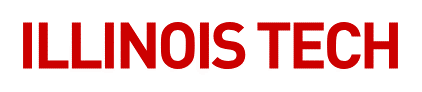

**SAM 503 ESG Analytics and Management**

Gaudy Solorzano-Morera, TA | Weslynne Ashton, Professor | Spring B 2026



### Lab Session 0— Introduction to Environmental, Social & Governance Data Analysis with python
---

**Learning Objectives**

By the end of this lab, you will be able to:
1. Get familiar with basic Python code and the main data‑science libraries
2. Load, explore, and clean ESG datasets using Pandas
3. Calculate and interpret key ESG metrics and scores
4. Visualize ESG data using Matplotlib and Seaborn
5. Perform simple statistical analysis on ESG variables

**Estimated time:** 60 minutes

---


### **Why and what is python?**

**Python is a simple, powerful programming language that tells a computer exactly what to do — and let you analyze data**

**Objects:**

Python is built from “things” called objects.
Everything in Python Is an Object. Think of objects like items in a "toolbox".

**Each item has: Data (what it is) and Abilities (what it can do)**

| Item | Why it's an object | Code Example |
|------|---------------------|--------------|
| Number | Numbers are objects with methods and behavior | `x = 10` |
| String (word) | Text is stored as a string object with methods | `name = "Alice"` |
| List | Lists are objects that hold collections of items | `fruits = ["apple", "banana"]` |
| DataFrame | DataFrames are objects for table data | `df = pd.DataFrame()` |
| Function | Functions are objects you can store, pass, or call | `def greet(): print("hi")` |
---

**Main Concepts you will see all around this notebook**

2. Libraries: Python comes with basic tools You can “import” to use as pre-recorded functions and classes that someone else wrote. For examples:

    * pandas → work with tables and spreadsheets
    * numpy → math and statistics
    * matplotlib / seaborn → graphs
    * plotly → interactive charts
    * scikit‑learn → machine learning

3. Functions are reusable actions. A block of code that performs a specific task. A function is a small machine that does something for you.
When you want to group data and behavior together you use Classes -that are a blueprint.

4. Variables are containers that store information. A variable is just a name you give to something.

Summary:

| Concept   | What it means | Code Example |
|-----------|----------------|--------------|
| **Library** | A collection of tools you can import to add new features to Python. | ```import pandas as pd``` |
| **Function** | A reusable block of code that performs a task. | ```def add(a, b):    return a + b``` |
| **Variable** | A name that stores a value. Like a label on a box. | ```age = 25``` |
---


5. Data structures are ways to organize information. Python has several built‑in data structures that help you store and organize data:

| Data Structure |	What it is	| Code Example |
|---|---|---|
| list	| ordered collection (you can change it)|	fruits = ["apple", "banana", "orange"] |
|dict	| key–value pairs (labels → values)|	person = {"name": "Alice", "age": 25}
| tuple |	ordered but unchangeable	| coordinates = (40.7, -74.0)|
| set	| collection of unique items (no duplicates, no order)	| unique_nums = {1, 2, 3, 3} → {1, 2, 3}

**Python is a simple language built from objects, libraries, variables, functions, and data structures — once you understand these pieces, you can analyze any dataset.**

## Part 1: Setup & Data Loading

We start by installing any required packages and importing the libraries we'll use throughout the lab.

In [9]:
# Install any packages not already available in Colab
# (Most are pre-installed, but we add plotly for interactive charts)
!pip install plotly --quiet

In [10]:
# --- Import Libraries ---
import pandas as pd              # Pandas — data manipulation, tables, DataFrames
import numpy as np               # NumPy — numerical computing, arrays, math operations
import matplotlib.pyplot as plt  # Matplotlib — basic plotting and data visualization
import matplotlib.patches as mpatches  # Matplotlib patches — shapes, legends, custom plot elements
import seaborn as sns            # Seaborn — statistical visualizations built on Matplotlib
import plotly.express as px      # Plotly Express — quick interactive plots
import plotly.graph_objects as go  # Plotly Graph Objects — detailed, customizable interactive charts
from plotly.subplots import make_subplots  # Plotly — create complex multi‑panel figures
import warnings                  # Warnings — control or suppress warning messages
warnings.filterwarnings('ignore')  # Ignore warnings to keep output clean


# Set a clean visual style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


### 1.1 Creating a Synthetic ESG Dataset

In a real project you would connect to providers like **MSCI**, **Sustainalytics**, **Bloomberg ESG**, or pull data from public sources such as the CDP or UN Global Compact.

For this lab, we generate a realistic synthetic dataset of **50 publicly listed companies** across multiple sectors, containing:

| Column | Description |
|---|---|
| `Company` | Company name |
| `Sector` | Industry sector |
| `Country` | Headquarters country |
| `E_Score` | Environmental score (0–100) |
| `S_Score` | Social score (0–100) |
| `G_Score` | Governance score (0–100) |
| `CO2_Emissions_tCO2e` | Annual CO₂ equivalent emissions (tonnes) |
| `Energy_Renewable_pct` | % of energy from renewable sources |
| `Employee_Satisfaction` | Employee satisfaction index (0–10) |
| `Board_Diversity_pct` | % of board seats held by women |
| `Revenue_M` | Annual revenue (USD millions) |
| `Market_Cap_M` | Market capitalisation (USD millions) |
| `ROE_pct` | Return on Equity (%) |

In [11]:
np.random.seed(42)  # Makes the random numbers repeat every time (so results stay the same)

n = 50  # We want data for 50 companies

# List of possible business sectors a company can belong to
sectors = ['Energy', 'Technology', 'Healthcare', 'Financials',
           'Consumer Staples', 'Industrials', 'Materials', 'Utilities']

# List of countries where companies might be located
countries = ['USA', 'UK', 'Germany', 'France', 'Japan',
             'Canada', 'Australia', 'Netherlands']

# List of 50 made‑up company names
company_names = [
    'AlphaGreen Corp', 'BetaRenew Ltd', 'ClearPath Inc', 'DeltaCarbon Co', 'EcoFront SA',
    'FutureSafe AG', 'GreenAxis PLC', 'HorizonESG Ltd', 'ImpactNow Corp', 'JustCause Inc',
    'KlearVision SA', 'LongView AG', 'MoralTech PLC', 'NovaSustain Ltd', 'OpenGate Inc',
    'PurePath Corp', 'QualityFirst SA', 'RenewEdge AG', 'SafeHarbour PLC', 'TrueNorth Ltd',
    'UltraGreen Corp', 'ValueChain Inc', 'WorldFirst SA', 'XcelImpact AG', 'YieldGood PLC',
    'ZeroCarbon Ltd', 'AquaBalance Inc', 'BioBridge Corp', 'CleanSlate SA', 'DataEthics AG',
    'EarthFirst PLC', 'FairTrade Ltd', 'GlobeGood Inc', 'HumanKind Corp', 'InnoSustain SA',
    'JointVenture AG', 'KindCorp PLC', 'LeafTech Ltd', 'MindfulInvest Inc', 'NatureLink Corp',
    'OceanGuard SA', 'PlanetPro AG', 'QGreen PLC', 'ReclaimCo Ltd', 'SoilFirst Inc',
    'TreeBridge Corp', 'UrbanFarm SA', 'VerdantRise AG', 'WaterCycle PLC', 'ZenithESG Ltd'
]

# Randomly choose a sector for each company
sector_list = np.random.choice(sectors, n)

# Some sectors usually have better or worse environmental scores
# (Energy tends to score lower, Technology tends to score higher, etc.)
sector_e_bias = {'Energy': -20, 'Technology': 10, 'Healthcare': 5,
                 'Financials': 5, 'Consumer Staples': 0, 'Industrials': -10,
                 'Materials': -15, 'Utilities': -5}

# Create environmental scores (E), influenced by the sector bias
# np.clip keeps the values withing a certain range. In this case between 10 and 99
e_scores = np.clip([np.random.normal(55 + sector_e_bias[s], 15) for s in sector_list], 10, 99)

# Create social (S) and governance (G) scores with random values
s_scores = np.clip(np.random.normal(60, 14, n), 10, 99)
g_scores = np.clip(np.random.normal(58, 16, n), 10, 99)

# Build the dataset as a table (DataFrame)
df = pd.DataFrame({
    'Company': company_names,                         # Company name
    'Sector': sector_list,                            # Sector assigned earlier
    'Country': np.random.choice(countries, n),        # Random country
    'E_Score': e_scores.round(1),                     # Environmental score
    'S_Score': s_scores.round(1),                     # Social score
    'G_Score': g_scores.round(1),                     # Governance score
    'CO2_Emissions_tCO2e': np.abs(np.random.normal(500000, 300000, n)).round(0),  # CO2 emissions
    'Energy_Renewable_pct': np.clip(np.random.normal(40, 25, n), 0, 100).round(1), # % renewable energy
    'Employee_Satisfaction': np.clip(np.random.normal(6.5, 1.5, n), 1, 10).round(1), # Employee happiness
    'Board_Diversity_pct': np.clip(np.random.normal(35, 15, n), 5, 65).round(1),     # % diversity on board
    'Revenue_M': np.abs(np.random.normal(8000, 5000, n)).round(0),                   # Revenue in millions
    'Market_Cap_M': np.abs(np.random.normal(20000, 15000, n)).round(0),              # Market cap in millions
    'ROE_pct': np.clip(np.random.normal(12, 8, n), -5, 40).round(1),                 # Return on equity
})

# Add a few missing values to make the dataset more realistic
df.loc[np.random.choice(df.index, 5, replace=False), 'Energy_Renewable_pct'] = np.nan
df.loc[np.random.choice(df.index, 3, replace=False), 'Board_Diversity_pct'] = np.nan

# Print how big the dataset is
print(f'Dataset created: {df.shape[0]} companies, {df.shape[1]} columns')

# Show the first 10 rows of the dataset
df.head(10)


Dataset created: 50 companies, 13 columns


,Company,Sector,Country,E_Score,S_Score,G_Score,CO2_Emissions_tCO2e,Energy_Renewable_pct,Employee_Satisfaction,Board_Diversity_pct,Revenue_M,Market_Cap_M,ROE_pct
0,AlphaGreen Corp,Materials,Australia,30.6,99.0,70.3,641971.0,0.0,6.3,22.6,9709.0,44429.0,6.8
1,BetaRenew Ltd,Financials,Germany,69.0,47.1,39.6,478151.0,44.7,7.4,30.2,17381.0,702.0,3.3
2,ClearPath Inc,Consumer Staples,USA,93.4,54.4,45.6,245962.0,23.5,6.9,41.2,12752.0,5551.0,25.5
3,DeltaCarbon Co,Materials,Netherlands,45.9,59.1,70.4,45546.0,61.3,5.6,26.5,5115.0,19167.0,19.1
4,EcoFront SA,Healthcare,USA,61.8,40.1,45.2,366046.0,20.2,6.2,22.7,3508.0,25761.0,11.9
5,FutureSafe AG,Utilities,Netherlands,42.3,74.6,80.1,756920.0,37.1,5.8,38.7,10460.0,19510.0,23.8
6,GreenAxis PLC,Consumer Staples,France,46.0,72.6,80.5,564228.0,NaN,5.6,38.7,1399.0,11012.0,12.6
7,HorizonESG Ltd,Consumer Staples,Germany,69.2,60.3,80.3,126278.0,61.6,7.8,27.4,17157.0,18663.0,5.1
8,ImpactNow Corp,Materials,Germany,44.4,52.5,43.9,551954.0,10.0,7.0,NaN,13897.0,433.0,24.2
9,JustCause Inc,Technology,Canada,55.5,39.1,59.2,615595.0,31.6,5.5,38.5,5654.0,30045.0,16.3


In [12]:
# 1. See the structure of your dataset
df.info()

# 2. See the names of your columns
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Company                50 non-null     object 
 1   Sector                 50 non-null     object 
 2   Country                50 non-null     object 
 3   E_Score                50 non-null     float64
 4   S_Score                50 non-null     float64
 5   G_Score                50 non-null     float64
 6   CO2_Emissions_tCO2e    50 non-null     float64
 7   Energy_Renewable_pct   45 non-null     float64
 8   Employee_Satisfaction  50 non-null     float64
 9   Board_Diversity_pct    47 non-null     float64
 10  Revenue_M              50 non-null     float64
 11  Market_Cap_M           50 non-null     float64
 12  ROE_pct                50 non-null     float64
dtypes: float64(10), object(3)
memory usage: 5.2+ KB


Index(['Company', 'Sector', 'Country', 'E_Score', 'S_Score', 'G_Score',
       'CO2_Emissions_tCO2e', 'Energy_Renewable_pct', 'Employee_Satisfaction',
       'Board_Diversity_pct', 'Revenue_M', 'Market_Cap_M', 'ROE_pct'],
      dtype='object')

---
## Part 2: Exploratory Data Analysis (EDA)

Before building any models or scores, we must **understand** our data.

In [13]:
# Basic dataset info
print('=== Dataset Info ===')
df.info()
print()
print('=== Missing Values ===')
print(df.isnull().sum())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Company                50 non-null     object 
 1   Sector                 50 non-null     object 
 2   Country                50 non-null     object 
 3   E_Score                50 non-null     float64
 4   S_Score                50 non-null     float64
 5   G_Score                50 non-null     float64
 6   CO2_Emissions_tCO2e    50 non-null     float64
 7   Energy_Renewable_pct   45 non-null     float64
 8   Employee_Satisfaction  50 non-null     float64
 9   Board_Diversity_pct    47 non-null     float64
 10  Revenue_M              50 non-null     float64
 11  Market_Cap_M           50 non-null     float64
 12  ROE_pct                50 non-null     float64
dtypes: float64(10), object(3)
memory usage: 5.2+ KB

=== Missing Values ===
Company            

#Analysis:
Our dataset has 50 companies and 13 columns of information. Most columns are complete, but two of them have missing values:

Energy_Renewable_pct is missing 5 values
Board_Diversity_pct is missing 3 values

Everything else has all 50 entries filled in. The data types look correct: text columns are shown as object, and all numeric columns are float64.

In [14]:
# Summary statistics for ESG scores
esg_cols = ['E_Score', 'S_Score', 'G_Score',
            'CO2_Emissions_tCO2e', 'Energy_Renewable_pct',
            'Employee_Satisfaction', 'Board_Diversity_pct']

df[esg_cols].describe().round(2)

,E_Score,S_Score,G_Score,CO2_Emissions_tCO2e,Energy_Renewable_pct,Employee_Satisfaction,Board_Diversity_pct
count,50.00,50.00,50.00,50.00,45.00,50.00,47.00
mean,54.14,58.46,62.03,534724.80,38.48,6.79,34.89
std,16.31,13.15,15.37,312560.51,26.93,1.06,13.08
min,24.80,22.80,35.00,16185.00,0.00,4.70,5.00
25%,44.40,52.85,47.02,290186.75,16.80,6.05,23.90
50%,51.85,57.35,66.50,549036.00,37.10,6.80,35.20
75%,65.95,64.80,74.22,694106.75,59.40,7.57,41.10
max,93.40,99.00,98.60,1655819.00,93.30,9.60,65.00


This table shows basic statistics for the numeric columns in your dataset. Here’s what it tells us:

Average ESG scores are around:
E_Score: 54
S_Score: 58
G_Score: 62

CO₂ emissions vary a lot — from about 16,000 to 1.6 million tons.
Renewable energy use ranges from 0% to 93%, with an average of 38%.
Employee satisfaction is fairly high, averaging around 6.8 out of 10.
Board diversity averages 35%, but ranges from 5% to 65%.

The std (standard deviation) values show that many columns have wide variation, meaning companies differ a lot from each other.

### 2.1 Distribution of E, S, and G Scores

Let's visualise how scores are distributed across our sample.

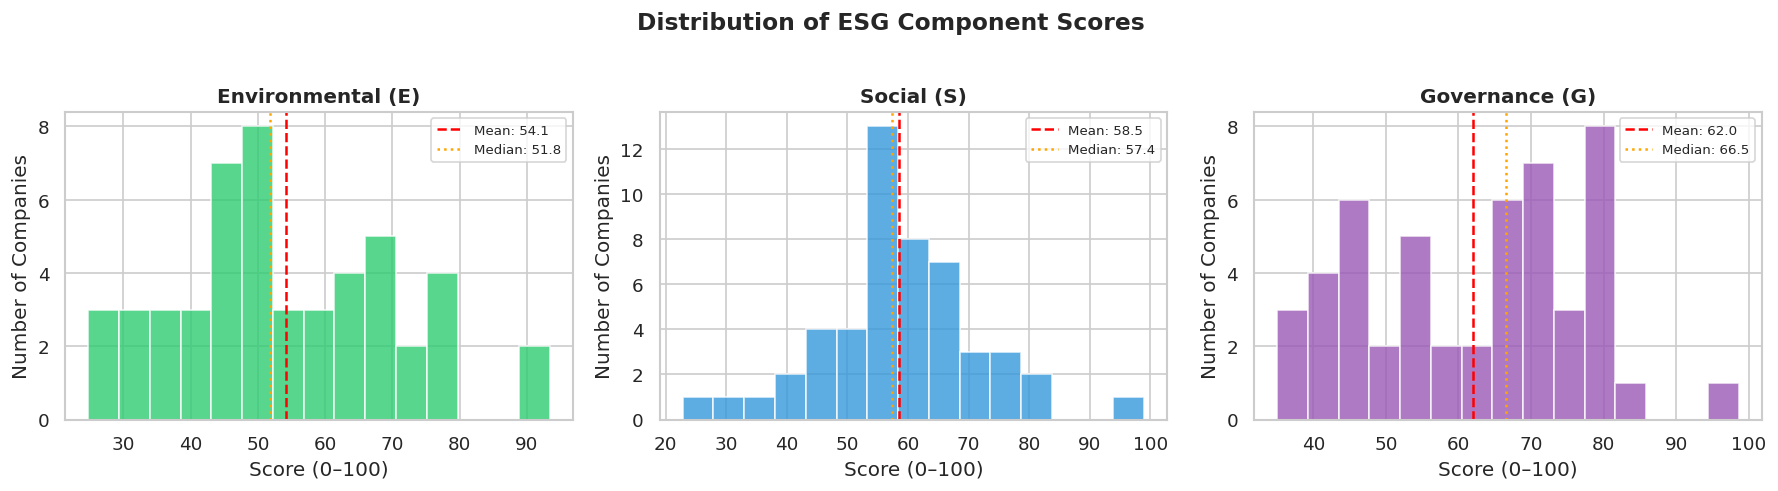

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Create 1 row and 3 side‑by‑side plots (for E, S, and G scores)

colours = ['#2ecc71', '#3498db', '#9b59b6']
# Colors for each plot (green, blue, purple)

labels  = ['Environmental (E)', 'Social (S)', 'Governance (G)']
# Titles for each plot

columns = ['E_Score', 'S_Score', 'G_Score']
# The actual column names in the DataFrame

# Loop through all three plots at once
for ax, col, colour, label in zip(axes, columns, colours, labels):

    ax.hist(df[col], bins=15, color=colour, alpha=0.8, edgecolor='white')
    # Make a histogram (a bar chart showing how scores are distributed)

    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {df[col].mean():.1f}')
    # Draw a red dashed line showing the average score

    ax.axvline(df[col].median(), color='orange', linestyle=':', linewidth=1.5,
               label=f'Median: {df[col].median():.1f}')
    # Draw an orange dotted line showing the middle score

    ax.set_title(label, fontweight='bold')
    # Set the title of the plot (E, S, or G)

    ax.set_xlabel('Score (0–100)')
    # Label the x‑axis

    ax.set_ylabel('Number of Companies')
    # Label the y‑axis

    ax.legend(fontsize=8)
    # Show the legend explaining the lines

plt.suptitle('Distribution of ESG Component Scores', fontsize=14, fontweight='bold', y=1.02)
# Big title for all three plots together

plt.tight_layout()
# Make  plots don’t overlap

plt.show()
# Display the final figure


| Pillar |	Mean |	Median |	Skew | Analysis |
|---|---|---|---|---|
| `Enviromental` |	54.1 |	51.8 |	Slight right	| Many mid‑range performers; few leaders |
| `Social` |	58.5 |	57.4 |	Near‑symmetric	|Consistent, moderate performance |
| `Governance`|	62.0 |	66.5 |	Left |	Strong governance maturity|

### 2.2 ESG Scores by Sector

Different industries have very different ESG profiles. Let's explore this.

In [16]:
# Average ESG scores per sector
sector_avg = (
    df.groupby('Sector')[['E_Score', 'S_Score', 'G_Score']]
      .mean()
      .round(1)   # ← 1 decimal place
      .sort_values('E_Score', ascending=False)
)


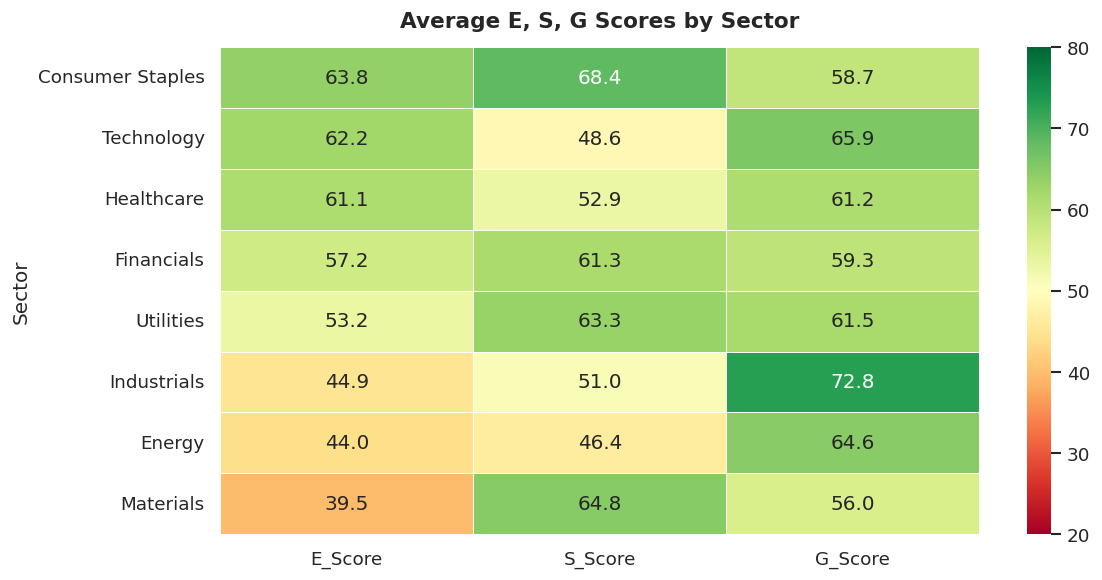

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
# Create a figure and one plot (ax) with a size of 10x5 inches

sns.heatmap(
    sector_avg,              # The data we want to show (average ESG scores per sector)
    annot=True, fmt='.1f',   # Write the numbers inside the boxes, with 1 decimal place
    cmap='RdYlGn',           # Color map: red = low values, green = high values
    linewidths=0.5,          # Thin lines between the boxes
    vmin=20, vmax=80,        # Fix the color scale between 20 and 80 for consistency
    ax=ax                    # Draw the heatmap on our plot
)

ax.set_title('Average E, S, G Scores by Sector', fontsize=13, fontweight='bold', pad=12)
# Add a title above the heatmap

ax.set_xlabel('')
# Remove the x‑axis label (not needed)

ax.set_ylabel('Sector')
# Label the y‑axis

plt.tight_layout()
# Make sure everything fits nicely and nothing overlaps

plt.show()
# Display the final heatmap


---
## Part 3: Data Cleaning

Real ESG data is messy. We need to handle **missing values** before analysis.

In [18]:
print('Missing values BEFORE cleaning:')
print(df.isnull().sum()[df.isnull().sum() > 0])
# Show which columns have missing values and how many

# Strategy 1: Fill missing renewable‑energy values using the MEDIAN of each sector
df['Energy_Renewable_pct'] = df.groupby('Sector')['Energy_Renewable_pct'].transform(
    lambda x: x.fillna(x.median())
)
# Explanation:
# - Group the data by sector (Energy, Tech, etc.)
# - For each sector, find the median renewable‑energy value
# - Replace missing values with that sector's median
# This is smarter than using one global number for all companies

# Strategy 2: Fill missing board‑diversity values using the GLOBAL median
df['Board_Diversity_pct'] = df['Board_Diversity_pct'].fillna(
    df['Board_Diversity_pct'].median()
)
# Explanation:
# - Take the median of the whole column
# - Replace missing values with that number
# - Simpler method because board diversity may not depend strongly on sector

print('\nMissing values AFTER cleaning:')
print(df.isnull().sum().sum(), '— all clear ✅')
# Count all remaining missing values in the entire dataset
# If the result is 0, everything has been successfully filled


Missing values BEFORE cleaning:
Energy_Renewable_pct    5
Board_Diversity_pct     3
dtype: int64

Missing values AFTER cleaning:
0 — all clear ✅


---
## Part 4: Building a Composite ESG Score

A **composite ESG score** aggregates the three pillars into a single number. Different providers weight pillars differently — here we explore two approaches.

**Approach A — Equal weights:** ESG = (E + S + G) / 3  
**Approach B — Sector-adjusted weights:** Weight E more heavily for polluting sectors

In [19]:
# --- Approach A: Equal-weighted composite score ---
df['ESG_Score_Equal'] = ((df['E_Score'] + df['S_Score'] + df['G_Score']) / 3).round(1)
# Take the average of E, S, and G scores (each weighted equally)
# Store the result in a new column called ESG_Score_Equal


# --- Approach B: Sector-adjusted weights ---
# High-emission sectors: weight E at 50%, S at 25%, G at 25%
# Low-emission sectors:  weight E at 25%, S at 40%, G at 35%

high_emission = ['Energy', 'Materials', 'Industrials', 'Utilities']
# List of sectors considered "high emission"


def sector_weighted_esg(row):
    # This function calculates a weighted ESG score for ONE company (one row)

    if row['Sector'] in high_emission:
        # If the company is in a high-emission sector:
        return round(row['E_Score']*0.50 + row['S_Score']*0.25 + row['G_Score']*0.25, 1)
    else:
        # If the company is in a low-emission sector:
        return round(row['E_Score']*0.25 + row['S_Score']*0.40 + row['G_Score']*0.35, 1)


df['ESG_Score_Weighted'] = df.apply(sector_weighted_esg, axis=1)
# Apply the function to every row in the dataset
# Create a new column with the weighted ESG score


# Compare the two approaches
comparison = df[['Company', 'Sector', 'E_Score', 'S_Score', 'G_Score',
                 'ESG_Score_Equal', 'ESG_Score_Weighted']].sort_values(
                     'ESG_Score_Equal', ascending=False).head(10)
# Select key columns and show the top 10 companies by equal-weighted ESG score

print('Top 10 Companies by Equal-Weighted ESG Score:')
comparison


Top 10 Companies by Equal-Weighted ESG Score:


,Company,Sector,E_Score,S_Score,G_Score,ESG_Score_Equal,ESG_Score_Weighted
18,SafeHarbour PLC,Utilities,91.7,79.2,66.6,79.2,82.3
29,DataEthics AG,Financials,62.0,56.0,98.6,72.2,72.4
7,HorizonESG Ltd,Consumer Staples,69.2,60.3,80.3,69.9,69.5
42,QGreen PLC,Technology,77.5,50.8,74.8,67.7,65.9
48,WaterCycle PLC,Industrials,67.4,64.8,70.3,67.5,67.5
24,YieldGood PLC,Financials,71.6,77.8,52.3,67.2,67.3
40,OceanGuard SA,Healthcare,77.7,61.4,60.8,66.6,65.3
0,AlphaGreen Corp,Materials,30.6,99.0,70.3,66.6,57.6
6,GreenAxis PLC,Consumer Staples,46.0,72.6,80.5,66.4,68.7
5,FutureSafe AG,Utilities,42.3,74.6,80.1,65.7,59.8


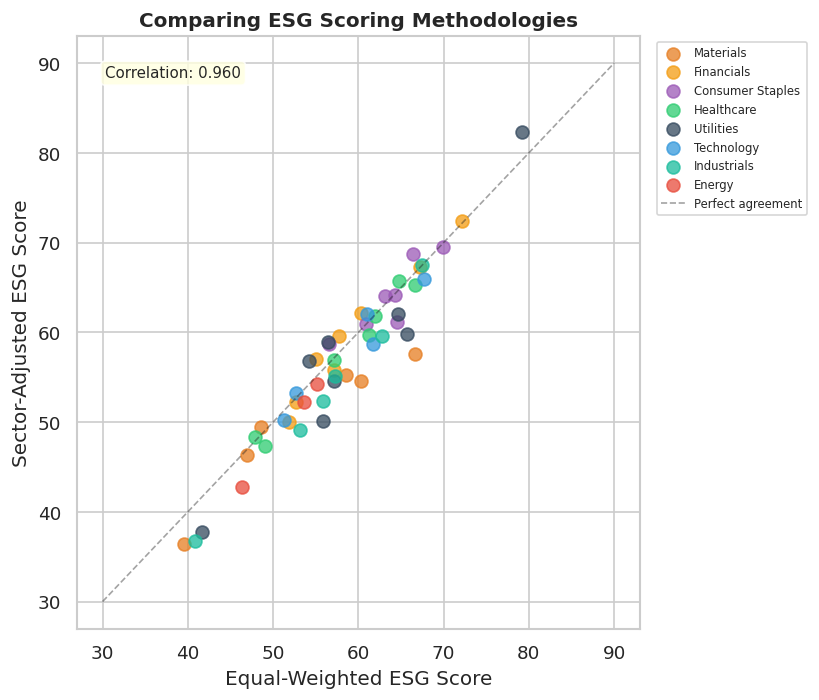

In [20]:
# Scatter plot: Do the two scoring methods agree?
#If they differ a lot, then: sector context really matters some companies look better or worse depending on the method they use

fig, ax = plt.subplots(figsize=(7, 6))
# Create a figure and one plotting area (ax) with a size of 7x6 inches


# Assign a unique colour to each sector
sector_colours = {
    s: c for s, c in zip(sectors,
    ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22','#34495e'])
}
# This creates a dictionary like:
# {'Energy': red, 'Tech': blue, ...}
# so each sector gets its own colour in the scatter plot


# Plot each sector separately so they appear in different colours
for sector in df['Sector'].unique():
    mask = df['Sector'] == sector
    # mask = True for rows belonging to this sector

    ax.scatter(
        df.loc[mask, 'ESG_Score_Equal'],      # x‑axis: equal‑weighted score
        df.loc[mask, 'ESG_Score_Weighted'],   # y‑axis: weighted score
        label=sector,
        color=sector_colours[sector],
        alpha=0.75,                           # slightly transparent points
        s=60                                  # point size
    )


# Perfect agreement line (45-degree line)
lims = [30, 90]
ax.plot(lims, lims, 'k--', alpha=0.4, linewidth=1, label='Perfect agreement')
# This draws a diagonal dashed line.
# If both scoring methods gave identical results, all points would lie on this line.


# Axis labels and title
ax.set_xlabel('Equal-Weighted ESG Score')
ax.set_ylabel('Sector-Adjusted ESG Score')
ax.set_title('Comparing ESG Scoring Methodologies', fontweight='bold')


# Legend placed outside the plot
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)


# Calculate correlation between the two scoring methods
corr = df[['ESG_Score_Equal', 'ESG_Score_Weighted']].corr().iloc[0, 1]

# Display the correlation inside the plot
ax.text(
    0.05, 0.93,                     # position inside the plot (relative coordinates)
    f'Correlation: {corr:.3f}',     # text to display
    transform=ax.transAxes,         # ensures coordinates are relative to the axes
    fontsize=9,
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)
# This puts a small yellow box showing how strongly the two scores agree.


plt.tight_layout()
# Adjust spacing so nothing overlaps

plt.show()
# Display the final scatter plot


---
## Part 5: ESG & Financial Performance

A central question in sustainable finance: **Does ESG performance predict financial returns?**

We explore the relationship between ESG scores and Return on Equity (ROE).

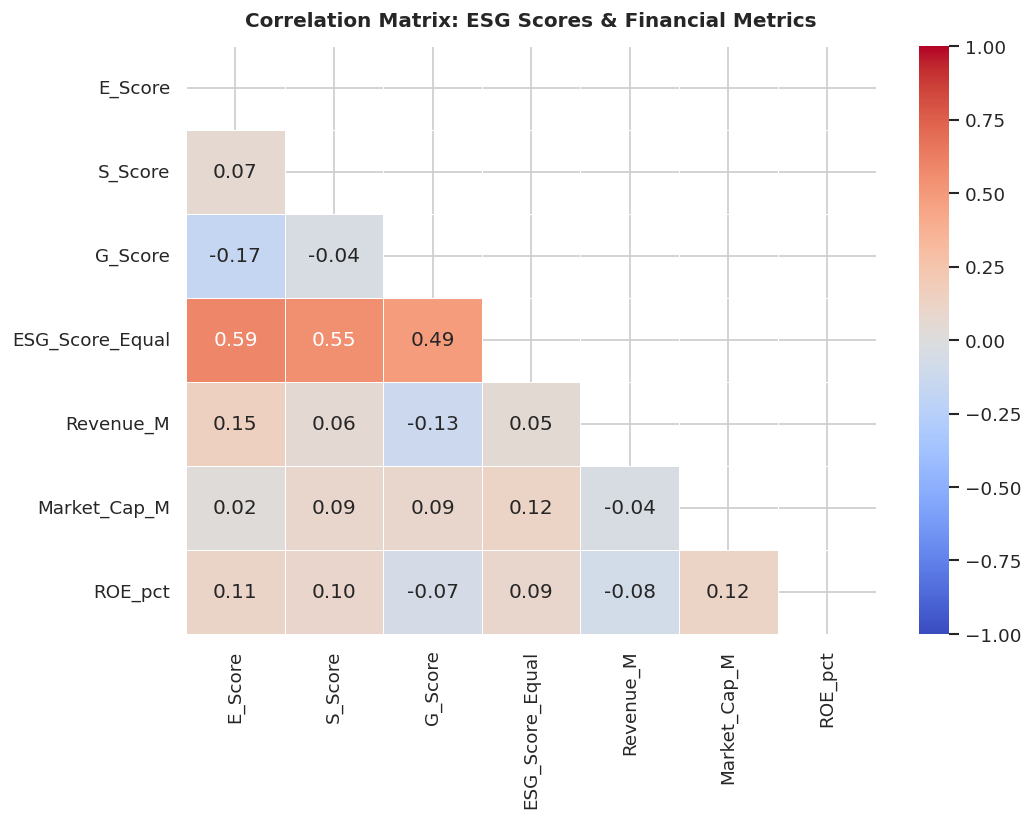

\ Key observation: Check the correlation between ESG scores and ROE_pct.
   In real datasets, the ESG-financial performance link is actively debated!


In [21]:
# Correlation matrix: ESG scores vs financial metrics

corr_cols = ['E_Score', 'S_Score', 'G_Score', 'ESG_Score_Equal',
             'Revenue_M', 'Market_Cap_M', 'ROE_pct']
# List of the columns we want to include in the correlation analysis


corr_matrix = df[corr_cols].corr().round(2)
# Calculate the correlation between all selected columns
# .corr() = correlation matrix
# .round(2) = show numbers with 2 decimals


fig, ax = plt.subplots(figsize=(9, 7))
# Create a figure and one plotting area (ax)


mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
# Create a mask to hide the UPPER triangle of the matrix
# (Correlation matrices are symmetrical, so we only need half)


sns.heatmap(
    corr_matrix,        # the correlation values
    mask=mask,          # hide the upper triangle
    annot=True,         # write the numbers inside the squares
    fmt='.2f',          # format numbers with 2 decimals
    cmap='coolwarm',    # blue = negative, red = positive
    center=0,           # color scale centered at zero
    vmin=-1, vmax=1,    # correlation always ranges from -1 to 1
    linewidths=0.5,     # thin lines between squares
    ax=ax               # draw on our plot
)


ax.set_title('Correlation Matrix: ESG Scores & Financial Metrics',
             fontsize=12, fontweight='bold', pad=12)
# Add a title above the heatmap


plt.tight_layout()
# Make sure everything fits nicely


plt.show()
# Display the heatmap


print('\ Key observation: Check the correlation between ESG scores and ROE_pct.')
print('   In real datasets, the ESG-financial performance link is actively debated!')
# Print a reminder to look at the ESG–ROE relationship


---
## Part 6: ESG Ratings & Classification

Rating agencies typically assign letter-grade ratings. Let's build one.

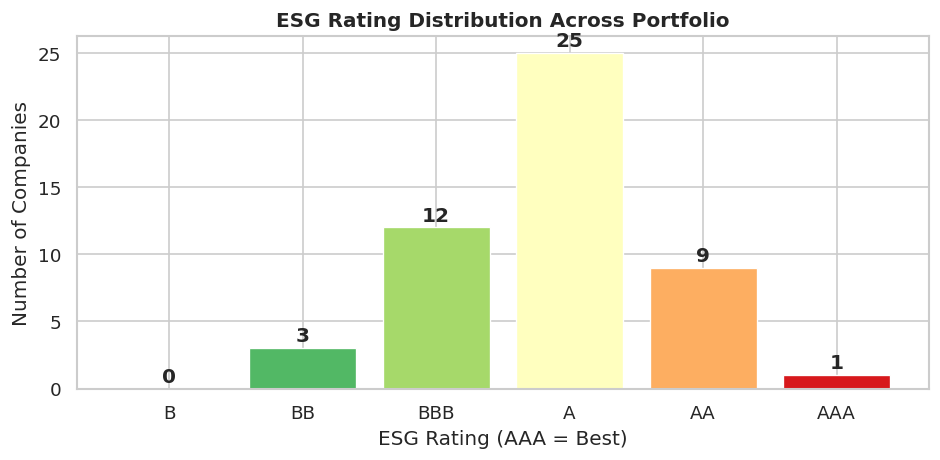

ESG_Rating
B       0
BB      3
BBB    12
A      25
AA      9
AAA     1
Name: count, dtype: int64


In [22]:
def assign_esg_rating(score):
    """Assign a letter rating based on composite ESG score."""

    # If the score is 75 or higher → best rating
    if score >= 75:
        return 'AAA'

    # If the score is 65–74 → very strong rating
    elif score >= 65:
        return 'AA'

    # If the score is 55–64 → strong rating
    elif score >= 55:
        return 'A'

    # If the score is 45–54 → average rating
    elif score >= 45:
        return 'BBB'

    # If the score is 35–44 → weak rating
    elif score >= 35:
        return 'BB'

    # Anything below 35 → very weak rating
    else:
        return 'B'


# Apply the rating function to each company's ESG score
df['ESG_Rating'] = df['ESG_Score_Equal'].apply(assign_esg_rating)
# This creates a new column called ESG_Rating with AAA, AA, A, etc.


# Count how many companies fall into each rating category
rating_counts = df['ESG_Rating'].value_counts().reindex(
    ['B', 'BB', 'BBB','A','AA','AAA'], fill_value=0
)
# .reindex ensures the ratings appear in the correct order


# Create a bar chart to show the distribution
fig, ax = plt.subplots(figsize=(8, 4))

# Colors for each rating bar (green = good, red = bad)
colours = ['#1a9641', '#52b865', '#a6d96a', '#ffffbf', '#fdae61', '#d7191c']

# Draw the bars
bars = ax.bar(rating_counts.index, rating_counts.values,
              color=colours, edgecolor='white', linewidth=0.8)


# Add the number of companies above each bar
for bar, val in zip(bars, rating_counts.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,   # horizontal position (center of bar)
        bar.get_height() + 0.2,            # vertical position (slightly above bar)
        str(val),                          # the number to display
        ha='center', va='bottom', fontweight='bold'
    )


# Titles and labels
ax.set_title('ESG Rating Distribution Across Portfolio',
             fontweight='bold', fontsize=12)
ax.set_xlabel('ESG Rating (AAA = Best)')
ax.set_ylabel('Number of Companies')

plt.tight_layout()
plt.show()

# Print the counts in the console
print(rating_counts)


---
## Part 7: Environmental Deep Dive — Carbon Intensity

**Carbon intensity** normalises emissions by revenue, enabling fair cross-company comparison.
This is a measure of carbon efficiency: How much CO₂ a company emits for every $1M it earns.
* High carbon intensity = poor environmental efficiency  
* Low carbon intensity = better environmental efficiency

In [23]:
# Carbon intensity = CO2 emissions per $1M revenue
df['Carbon_Intensity'] = (df['CO2_Emissions_tCO2e'] / df['Revenue_M']).round(1)

# Top 10 highest carbon intensity (most polluting per unit revenue)
top_polluters = df.nlargest(10, 'Carbon_Intensity')[['Company', 'Sector', 'Carbon_Intensity', 'E_Score']]
print('Top 10 Companies by Carbon Intensity (tCO2e per $M revenue):')
print(top_polluters.to_string(index=False))



Top 10 Companies by Carbon Intensity (tCO2e per $M revenue):
        Company           Sector  Carbon_Intensity  E_Score
   OpenGate Inc        Utilities           21690.6     46.6
AquaBalance Inc      Industrials            2389.7     24.8
  ReclaimCo Ltd        Utilities             886.5     54.4
 KlearVision SA       Healthcare             414.9     44.7
  GreenAxis PLC Consumer Staples             403.3     46.0
 ZeroCarbon Ltd      Industrials             353.7     36.9
TreeBridge Corp       Financials             257.3     58.9
UltraGreen Corp      Industrials             245.9     48.3
  DataEthics AG       Financials             170.9     62.0
  OceanGuard SA       Healthcare             163.6     77.7


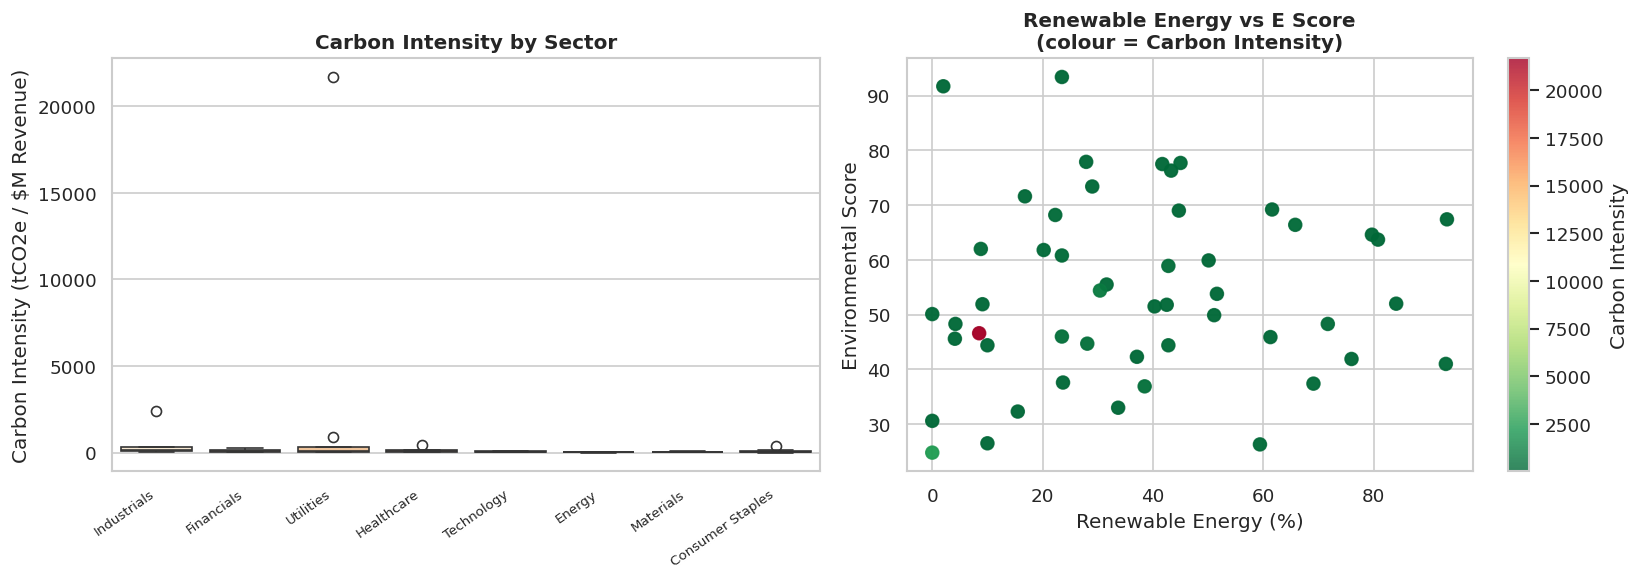

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Create a figure with TWO side‑by‑side plots (1 row, 2 columns)
# The whole figure is 14 inches wide and 5 inches tall


# ---------------- LEFT PLOT: Carbon intensity by sector ----------------

sector_order = df.groupby('Sector')['Carbon_Intensity'].median().sort_values(ascending=False).index
# Group companies by sector
# Calculate the median carbon intensity for each sector
# Sort sectors from highest → lowest carbon intensity
# This gives a nice order for the boxplot


sns.boxplot(
    data=df,
    x='Sector',
    y='Carbon_Intensity',
    order=sector_order,   # use the sorted order
    palette='OrRd',       # orange‑red color palette
    ax=axes[0]            # draw on the LEFT plot
)

axes[0].set_xticklabels(
    axes[0].get_xticklabels(),
    rotation=35, ha='right', fontsize=8
)
# Rotate sector names so they don’t overlap and are easier to read

axes[0].set_title('Carbon Intensity by Sector', fontweight='bold')
axes[0].set_ylabel('Carbon Intensity (tCO2e / $M Revenue)')
axes[0].set_xlabel('')
# Remove x‑axis label (not needed)


# ---------------- RIGHT PLOT: Renewable energy vs E‑Score ----------------

axes[1].scatter(
    df['Energy_Renewable_pct'],   # x‑axis: % renewable energy
    df['E_Score'],                # y‑axis: environmental score
    c=df['Carbon_Intensity'],     # color of each point = carbon intensity
    cmap='RdYlGn_r',              # red = high emissions, green = low emissions
    s=60,                         # point size
    alpha=0.8,                    # slightly transparent
    edgecolors='gray',
    linewidth=0.3
)
# This creates a scatter plot showing how renewable energy relates to E‑Score


# Create a second scatter object for the colorbar
sc = axes[1].scatter(
    df['Energy_Renewable_pct'],
    df['E_Score'],
    c=df['Carbon_Intensity'],
    cmap='RdYlGn_r',
    s=60,
    alpha=0.8
)

plt.colorbar(sc, ax=axes[1], label='Carbon Intensity')
# Add a color bar so viewers know what the colors mean


axes[1].set_xlabel('Renewable Energy (%)')
axes[1].set_ylabel('Environmental Score')
axes[1].set_title(
    'Renewable Energy vs E Score\n(colour = Carbon Intensity)',
    fontweight='bold'
)
# Add labels and a title to the RIGHT plot


plt.tight_layout()
# Make sure the two plots fit nicely without overlapping

plt.show()
# Display the final figure


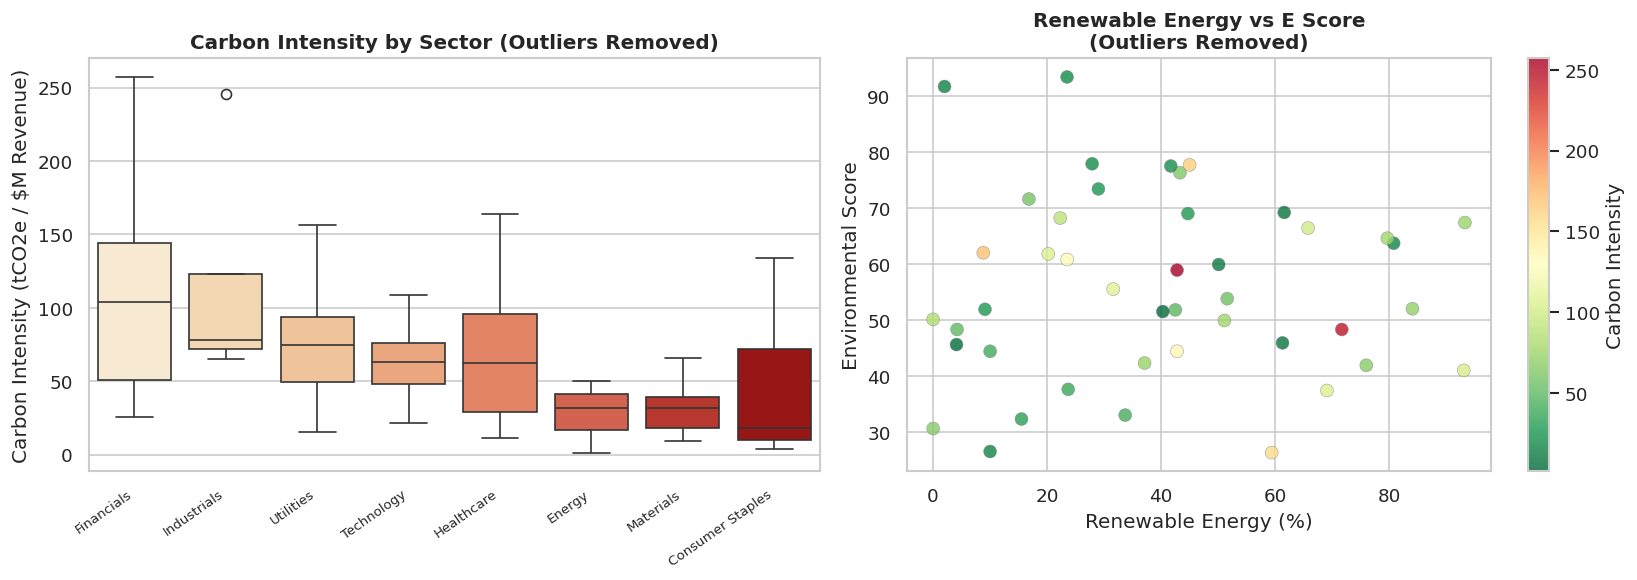

In [25]:
# ---------------- REMOVE OUTLIERS (Carbon_Intensity) ----------------

# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['Carbon_Intensity'].quantile(0.25)
Q3 = df['Carbon_Intensity'].quantile(0.75)

# Interquartile range
IQR = Q3 - Q1

# Define outlier cutoff (1.5 × IQR rule)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Keep only rows within the bounds (remove extreme outliers)
df_no_outliers = df[(df['Carbon_Intensity'] >= lower_bound) &
                    (df['Carbon_Intensity'] <= upper_bound)]

# ---------------- PLOTTING ----------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Create a figure with 2 side-by-side plots


# -------- LEFT PLOT: Carbon intensity by sector (boxplot) --------

# Order sectors by median carbon intensity (after removing outliers)
sector_order = (
    df_no_outliers.groupby('Sector')['Carbon_Intensity']
    .median()
    .sort_values(ascending=False)
    .index
)

sns.boxplot(
    data=df_no_outliers,
    x='Sector',
    y='Carbon_Intensity',
    order=sector_order,
    palette='OrRd',
    ax=axes[0]
)

axes[0].set_xticklabels(
    axes[0].get_xticklabels(),
    rotation=35, ha='right', fontsize=8
)

axes[0].set_title('Carbon Intensity by Sector (Outliers Removed)', fontweight='bold')
axes[0].set_ylabel('Carbon Intensity (tCO2e / $M Revenue)')
axes[0].set_xlabel('')


# -------- RIGHT PLOT: Renewable energy vs E Score --------

sc = axes[1].scatter(
    df_no_outliers['Energy_Renewable_pct'],   # x-axis
    df_no_outliers['E_Score'],                # y-axis
    c=df_no_outliers['Carbon_Intensity'],     # color = carbon intensity
    cmap='RdYlGn_r',
    s=60,
    alpha=0.8,
    edgecolors='gray',
    linewidth=0.3
)

plt.colorbar(sc, ax=axes[1], label='Carbon Intensity')

axes[1].set_xlabel('Renewable Energy (%)')
axes[1].set_ylabel('Environmental Score')
axes[1].set_title('Renewable Energy vs E Score\n(Outliers Removed)', fontweight='bold')


plt.tight_layout()
plt.show()


---
## Part 8: Portfolio ESG Dashboard

Finally, let's build an interactive radar chart — a common tool used by ESG analysts to profile companies.

In [26]:
# Select top 5 companies by composite ESG score for comparison
top5 = df.nlargest(5, 'ESG_Score_Equal')[   # pick the 5 rows with the highest ESG score
    ['Company', 'E_Score', 'S_Score', 'G_Score',
     'Energy_Renewable_pct', 'Board_Diversity_pct', 'Employee_Satisfaction']
].reset_index(drop=True)
# reset row numbers to 0–4


# Normalise Employee Satisfaction to 0-100
top5['Employee_Satisfaction_norm'] = (top5['Employee_Satisfaction'] * 10).round(1)
# Employee satisfaction was originally 0–10, so multiply by 10 to convert to 0–100


# Labels for the radar chart axes
categories = ['Environmental', 'Social', 'Governance',
              'Renewable Energy %', 'Board Diversity %', 'Employee Satisfaction']


fig = go.Figure()   # Create an empty radar chart figure


# Colors for each company’s radar shape
colours = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']


# Loop through each of the top 5 companies
for i, row in top5.iterrows():

    # Collect the values for this company in the same order as the categories
    values = [
        row['E_Score'], row['S_Score'], row['G_Score'],
        row['Energy_Renewable_pct'], row['Board_Diversity_pct'],
        row['Employee_Satisfaction_norm']
    ]

    values.append(values[0])
    # Add the first value again at the end to "close" the radar shape


    # Add one radar shape (polygon) for this company
    fig.add_trace(go.Scatterpolar(
        r=values,                               # distance from center (the numbers)
        theta=categories + [categories[0]],     # labels around the circle
        fill='toself',                          # fill the shape with color
        name=row['Company'],                    # company name in legend
        line_color=colours[i],                  # unique color
        opacity=0.6                             # slightly transparent
    ))


# Format the radar chart
fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 100])  # axis goes from 0 to 100
    ),
    showlegend=True,
    title='ESG Radar Chart — Top 5 Performers',
    title_x=0.5   # center the title
)

fig.show()   # Display the radar chart


---
## Part 9: Exercises 🎯

Complete the following tasks independently. Write your code in the empty cells below each task.

---

### Exercise 1 — Country-Level Analysis
Calculate the **average composite ESG score** for each country and produce a **bar chart** sorted from highest to lowest score.

In [27]:
# ✏️ Your code here

# 1. Calculate average ESG score per country


# 2. Plot the results using Plotly Express


# 3. Print the table


### Exercise 2 — Governance & Board Diversity
Plot the relationship between `Board_Diversity_pct` and `G_Score`. Is there a positive relationship? Calculate the Pearson correlation coefficient using `df[...].corr()`.

In [28]:
# ✏️ Your code here

# Create a scatter plot


# Calculate Pearson correlation coefficient


### Exercise 3 — Best-in-Class Screening
**Best-in-class** is an ESG investment strategy that selects the **top 30%** of companies within each sector by ESG score.

Filter `df` to keep only companies in the top 30% of `ESG_Score_Equal` within their sector. How many companies pass the screen? Which sector has the most?

In [29]:
# Hint: Use groupby + transform + quantile
# threshold = df.groupby('Sector')['ESG_Score_Equal'].transform(lambda x: x.quantile(0.7))

# ✏️ Your code here


---
## 📝 Lab Summary

In this lab you have:

| Step | Skill |
|------|-------|
| Created & loaded a dataset | `pandas` DataFrames |
| Explored distributions & sectors | `matplotlib`, `seaborn` histograms & heatmaps |
| Handled missing data | `.fillna()`, `groupby().transform()` |
| Built composite ESG scores | Weighted averages, custom functions |
| Analysed ESG–financial links | Correlation matrices, scatter plots |
| Assigned letter ratings | `apply()` with custom classification |
| Computed carbon intensity | Derived metrics & normalisation |
| Built an ESG radar chart | `plotly` polar plots |

---

*"Data is only as good as the questions you ask of it."* — Always interrogate methodology, data sources, and potential biases.

 ## **THANK YOU :D **